# Exact Diagonalization of the 1D Heisenberg XXZ Spin Chain

This notebook presents a comprehensive study of the 1D Heisenberg XXZ spin-1/2 chain using exact diagonalization (ED). We explore the energy spectrum, calculate the bipartite entanglement entropy, locate the critical point of the quantum phase transition, and perform finite-size scaling.


## 1. Theoretical Framework

The 1D Heisenberg XXZ model on a lattice of $N$ spin-1/2 particles is governed by the Hamiltonian:

$$H = J \sum_{i=1}^{N} \left( S_i^x S_{i+1}^x + S_i^y S_{i+1}^y + \Delta S_i^z S_{i+1}^z \right)$$

where $S_i^\alpha = \frac{1}{2} \sigma_i^\alpha$ (with $\sigma^\alpha$ being the Pauli matrices), $J$ is the exchange coupling constant (with $J > 0$ being antiferromagnetic), and $\Delta$ is the anisotropy parameter. Using the spin ladder operators $S^\pm = S^x \pm i S^y$, the Hamiltonian can be rewritten as:

$$H = J \sum_{i=1}^{N} \left[ \frac{1}{2} \left( S_i^+ S_{i+1}^- + S_i^- S_{i+1}^+ \right) + \Delta S_i^z S_{i+1}^z \right]$$

### Physical Phases of the XXZ Chain
At zero temperature, the XXZ model shows three distinct phases depending on $\Delta$:
1. **XY Phase ($\Delta < 1$)**: Gapless, critical phase. The spin correlations show power-law decay.
2. **Isotropic XXX Point ($\Delta = 1$)**: SU(2) symmetric point. It is gapless and is solved exactly by the Bethe ansatz.
3. **Ising / Néel Phase ($\Delta > 1$)**: Gapped phase. The ground state exhibits antiferromagnetic Néel order.


## 2. $S^z$ Symmetry and Basis Reduction

The total magnetization along the z-axis, $S^z_{\text{tot}} = \sum_{i=1}^N S_i^z$, commutes with the Hamiltonian: $[H, S^z_{\text{tot}}] = 0$. This conservation law block-diagonalizes the Hamiltonian by restricting our basis to sectors of fixed $S^z_{\text{tot}}$.

We restrict our study to the zero-magnetization sector $S^z_{\text{tot}} = 0$, where the number of up spins ($\uparrow$) equals the number of down spins ($\downarrow$). For an even number of spins $N$, the dimension of this subspace is:

$$\text{dim} = \binom{N}{N/2}$$

which grows much slower than the full Hilbert space dimension $2^N$.


In [1]:
import numpy as np
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Set high-quality styling for figures
rcParams.update({
    'font.size': 11,
    'figure.dpi': 120,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'font.family': 'serif'
})


### 2.1 Basis Representation

We represent each spin state as a binary integer of length $N$, where the $i$-th bit represents the spin at site $i$ ($1$ for $\uparrow$ and $0$ for $\downarrow$). The $S^z_{\text{tot}} = 0$ sector comprises integers with exactly $N/2$ set bits.


In [2]:
def generate_sz0_basis(N):
    """
    Generates the list of integer state representations corresponding to the 
    Sz = 0 (zero-magnetization) sector of an N-spin chain.
    """
    basis = []
    for state in range(1 << N):
        if bin(state).count('1') == N // 2:
            basis.append(state)
    return np.array(basis)


## 3. Hamiltonian Construction

We construct the Hamiltonian matrix using a sparse representation (`lil_matrix`).
- **Diagonal terms**: The longitudinal term $J \Delta S_i^z S_{i+1}^z$ contributes a diagonal energy of $+J\Delta/4$ if the spins at $i$ and $i+1$ are parallel, and $-J\Delta/4$ if they are antiparallel.
- **Off-diagonal terms**: The transverse term $\frac{J}{2}(S_i^+ S_{i+1}^- + S_i^- S_{i+1}^+)$ swaps adjacent antiparallel spins ($\uparrow\downarrow \leftrightarrow \downarrow\uparrow$) with coupling amplitude $J/2$.


In [3]:
def build_hamiltonian(N, J, Delta, pbc=True):
    """
    Constructs the XXZ Hamiltonian matrix in the Sz = 0 basis.
    
    Parameters:
        N (int): Number of spin sites.
        J (float): Exchange coupling constant.
        Delta (float): Anisotropy parameter.
        pbc (bool): Periodic boundary conditions.
        
    Returns:
        H (csr_matrix): Sparse Hamiltonian matrix in CSR format.
        basis (ndarray): Integer representations of the basis states.
    """
    basis = generate_sz0_basis(N)
    dim = len(basis)
    state_to_idx = {s: i for i, s in enumerate(basis)}

    H = lil_matrix((dim, dim))

    for idx, state in enumerate(basis):
        # 1. Diagonal terms: J * Delta * Sz_i * Sz_j
        diag = 0.0
        for i in range(N):
            j = (i + 1) % N if pbc else i + 1
            if j >= N:
                continue
            si = (state >> i) & 1
            sj = (state >> j) & 1
            diag += 1.0 if si == sj else -1.0
        H[idx, idx] = J * Delta * diag / 4.0

        # 2. Off-diagonal terms: J/2 * (S+_i S-_j + S-_i S+_j)
        for i in range(N):
            j = (i + 1) % N if pbc else i + 1
            if j >= N:
                continue
            si = (state >> i) & 1
            sj = (state >> j) & 1
            if si == 1 and sj == 0:
                # Flip 10 to 01
                new_state = state & ~(1 << i)
                new_state |= 1 << j
                H[idx, state_to_idx[new_state]] += J / 2.0
            elif si == 0 and sj == 1:
                # Flip 01 to 10
                new_state = state | (1 << i)
                new_state &= ~(1 << j)
                H[idx, state_to_idx[new_state]] += J / 2.0

    return H.tocsr(), basis


## 4. Entanglement Entropy

For a bipartite quantum system split into subsystem $A$ (first $k$ sites) and subsystem $B$ (remaining $N-k$ sites), the state can be Schmidt-decomposed as:

$$|\psi\rangle = \sum_{i} \lambda_i |i\rangle_A |i\rangle_B$$

The bipartite entanglement entropy (Von Neumann entropy) is defined as:

$$S_E = -\sum_{i} \lambda_i^2 \ln \lambda_i^2$$

where $\lambda_i^2$ are the eigenvalues of the reduced density matrix $\rho_A = \text{Tr}_B(|\psi\rangle\langle\psi|)$. We compute this by reshaping the ground state coefficient vector into a matrix $M$ of dimensions $2^k \times 2^{N-k}$ and running singular value decomposition (SVD):

$$M = U \Sigma V^\dagger$$

The singular values $\sigma_i$ of $M$ correspond exactly to the Schmidt coefficients $\lambda_i$.


In [4]:
def entanglement_entropy(psi, basis, N, k=None):
    """
    Computes the bipartite entanglement entropy of the state psi 
    between subsystem A (first k spins) and subsystem B (rest).
    """
    if k is None:
        k = N // 2

    dim_A = 1 << k
    dim_B = 1 << (N - k)
    M = np.zeros((dim_A, dim_B))

    for coeff, state in zip(psi, basis):
        a = state & ((1 << k) - 1)
        b = state >> k
        M[a, b] = coeff

    # SVD to find Schmidt coefficients
    _, s, _ = np.linalg.svd(M, full_matrices=False)
    s_sq = s[s > 1e-15] ** 2
    s_sq /= s_sq.sum()
    return -np.sum(s_sq * np.log(s_sq))


## 5. Anisotropy Scan & Energy Spectrum

We compute the energy spectrum of an $N=10$ spin chain for different anisotropy values $\Delta \in [0.3, 2.0]$. We plot the first 6 energy levels and examine how the energy gap between the first excited state ($E_1$) and ground state ($E_0$) behaves.


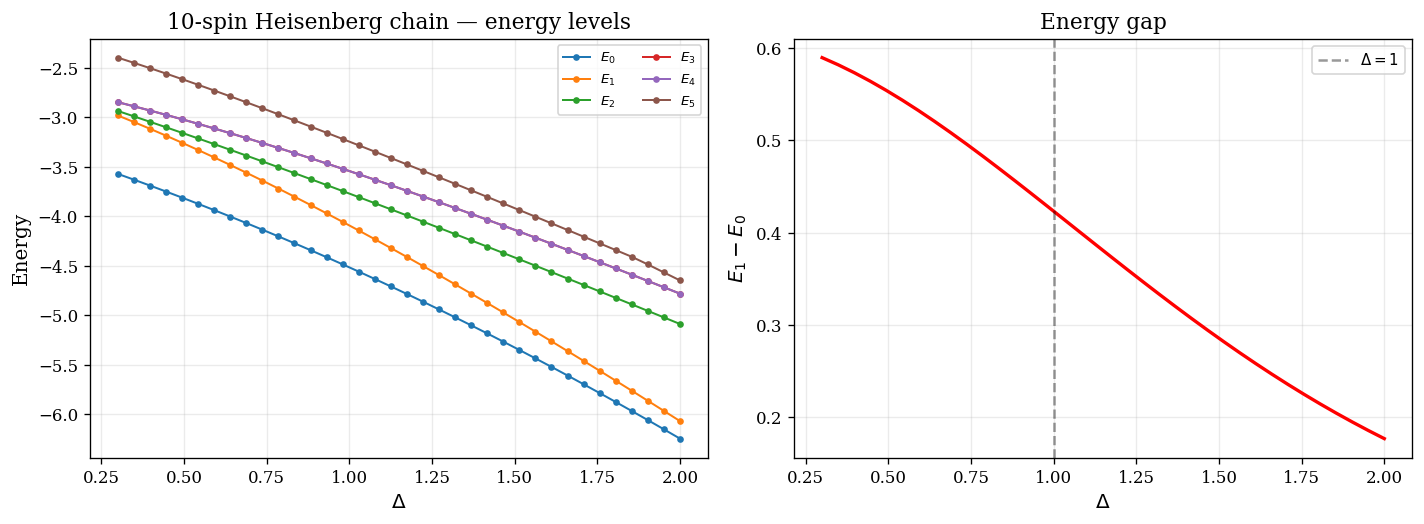

In [5]:
def fig_energy_spectrum(Delta_values, energies_all, N):
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4.5))
    n_states = energies_all.shape[1]
    for level in range(n_states):
        ax0.plot(Delta_values, energies_all[:, level], 'o-', lw=1.2, ms=3, label=f'$E_{level}$')
    ax0.set_xlabel(r'$\Delta$')
    ax0.set_ylabel('Energy')
    ax0.set_title(f'{N}-spin Heisenberg chain — energy levels')
    ax0.legend(fontsize=8, ncol=2)
    ax0.grid(True, alpha=0.25)

    gap = energies_all[:, 1] - energies_all[:, 0]
    ax1.plot(Delta_values, gap, 'r-', lw=2)
    ax1.axvline(x=1.0, color='k', ls='--', alpha=0.4, label=r'$\Delta=1$')
    ax1.set_xlabel(r'$\Delta$')
    ax1.set_ylabel('$E_1 - E_0$')
    ax1.set_title('Energy gap')
    ax1.legend()
    ax1.grid(True, alpha=0.25)
    fig.tight_layout()
    return fig

def compute_spectrum(N, J, Delta, pbc=True, k=5):
    H, basis = build_hamiltonian(N, J, Delta, pbc)
    evals, evecs = eigsh(H, k=k, which='SA')
    return evals, evecs, basis

# Execute spectrum computation
N = 10
J = 1.0
Delta_values = np.linspace(0.3, 2.0, 36)
n_states = 6
energies_all = np.zeros((len(Delta_values), n_states))

for i, Delta in enumerate(Delta_values):
    evals, *_ = compute_spectrum(N, J, Delta, k=n_states)
    energies_all[i] = evals

fig = fig_energy_spectrum(Delta_values, energies_all, N)
plt.savefig('energy_spectrum.png')
plt.show()


## 6. Quantum Phase Transition: Entanglement and Gap

At $\Delta = 1$, the XXZ chain undergoes a transition from the gapless XY phase to the gapped antiferromagnetic Ising phase. Here, we track both the entanglement entropy $S$ of the ground state and the energy gap $\Delta E = E_1 - E_0$.


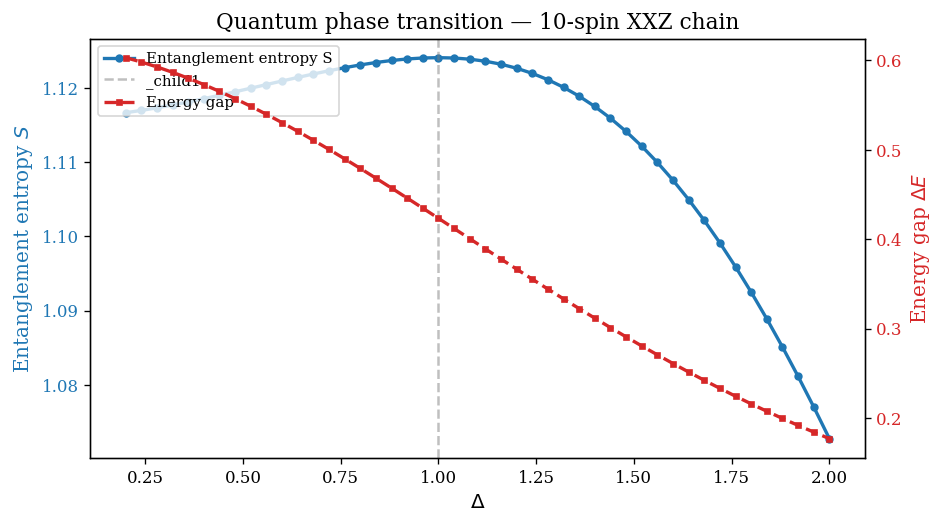

In [6]:
def fig_phase_transition(Delta_values, entropies, gaps, N):
    fig, ax1 = plt.subplots(figsize=(8, 4.5))
    ax1.plot(Delta_values, entropies, 'o-', color='tab:blue', lw=2, ms=4, label='Entanglement entropy S')
    ax1.set_xlabel(r'$\Delta$')
    ax1.set_ylabel('Entanglement entropy $S$', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.axvline(x=1.0, color='gray', ls='--', alpha=0.5)

    ax2 = ax1.twinx()
    ax2.plot(Delta_values, gaps, 's--', color='tab:red', lw=2, ms=3, label='Energy gap')
    ax2.set_ylabel(r'Energy gap $\Delta E$', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    lines = ax1.get_lines() + ax2.get_lines()
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left')

    ax1.set_title(f'Quantum phase transition — {N}-spin XXZ chain')
    fig.tight_layout()
    return fig

Delta_values_fine = np.linspace(0.2, 2.0, 46)
entropies, gaps = [], []

for i, Delta in enumerate(Delta_values_fine):
    evals, evecs, basis = compute_spectrum(N, J, Delta, k=3)
    psi_gs = evecs[:, 0]
    S = entanglement_entropy(psi_gs, basis, N)
    entropies.append(S)
    gaps.append(evals[1] - evals[0])

fig = fig_phase_transition(Delta_values_fine, entropies, gaps, N)
plt.savefig('phase_transition.png')
plt.show()


## 7. Finite-Size Scaling of Entanglement Entropy

According to conformal field theory (CFT), the ground-state entanglement entropy of a 1D critical system with periodic boundary conditions scales logarithmically with the subsystem size $l$:

$$S_E(l) \approx \frac{c}{3} \ln \left( \frac{N}{\pi} \sin \frac{\pi l}{N} \right) + \text{const}$$

where $c$ is the central charge. At the critical point $\Delta = 1$, the model has $c = 1$. Here we plot the half-chain entanglement entropy vs $\Delta$ for different system sizes $N = 8, 10, 12$ to observe scaling behavior.


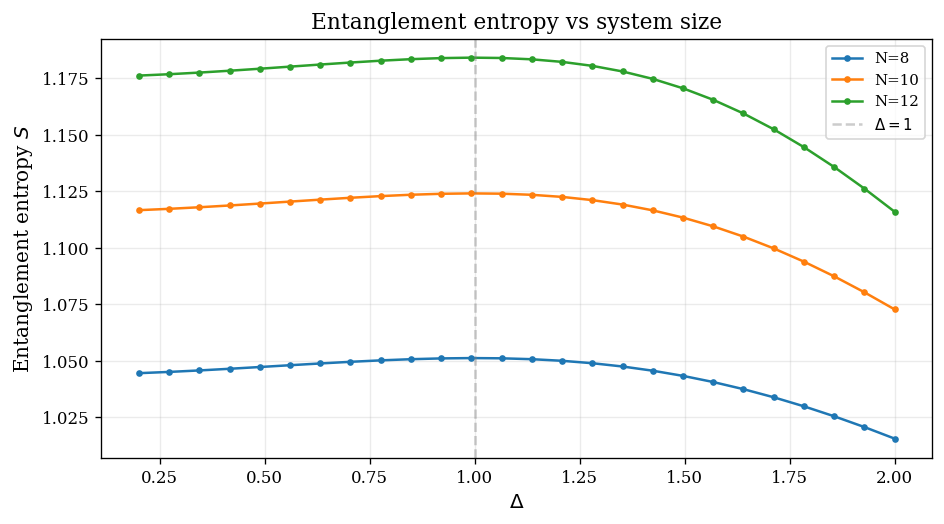

In [7]:
def fig_size_scaling(sizes, entropies_by_size, Delta_values):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for i, N in enumerate(sizes):
        ax.plot(Delta_values, entropies_by_size[i], 'o-', lw=1.5, ms=3, label=f'N={N}')
    ax.set_xlabel(r'$\Delta$')
    ax.set_ylabel('Entanglement entropy $S$')
    ax.set_title('Entanglement entropy vs system size')
    ax.axvline(x=1.0, color='gray', ls='--', alpha=0.4, label=r'$\Delta=1$')
    ax.legend()
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    return fig

sizes = [8, 10, 12]
Delta_coarse = np.linspace(0.2, 2.0, 26)
entropies_by_size = []

for Nc in sizes:
    S_list = []
    for Delta in Delta_coarse:
        evals, evecs, basis = compute_spectrum(Nc, J, Delta, k=2)
        psi_gs = evecs[:, 0]
        S_list.append(entanglement_entropy(psi_gs, basis, Nc))
    entropies_by_size.append(S_list)

fig = fig_size_scaling(sizes, entropies_by_size, Delta_coarse)
plt.savefig('size_scaling.png')
plt.show()


## 8. Summary of Results

- **Anisotropy dependence**: For $\Delta < 1$ (XY phase), the system remains critical and gapless in the thermodynamic limit. At $\Delta > 1$, a gap opens up in the excitation spectrum.
- **Phase Transition Signature**: The entanglement entropy peaks near the critical point $\Delta = 1$ and decreases as we move deep into the ordered antiferromagnetic phase ($\Delta > 1$), where the ground state becomes dominated by the Néel states $|\uparrow\downarrow\uparrow\downarrow\dots\rangle$ and $|\downarrow\uparrow\downarrow\uparrow\dots\rangle$.
- **Size Scaling**: The peak value of the entanglement entropy at $\Delta = 1$ grows with system size $N$, reflecting the logarithmic divergence characteristic of critical spin systems.
